cell 1: Libraries

In [ ]:
!pip install transformers accelerate bitsandbytes Pillow gTTS -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.1 MB/s eta 0:00:00


cell 2: Load Model

In [ ]:
import torch, os, io
from transformers import LlavaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from PIL import Image
from gtts import gTTS
from IPython.display import display, Audio
import gc

print("Loading LLaVA-1.5-7b (4-bit)... please wait 4-5 minutes")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model_id = "llava-hf/llava-1.5-7b-hf"
processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)
model.eval()

print(f"✅ Model loaded on: {next(model.parameters()).device}")

Loading LLaVA-1.5-7b (4-bit)... please wait 4-5 minutes


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✅ Model loaded on: cuda:0


cell 3: Prompt

In [ ]:
def describe_image(image, mode="short"):
    if mode == "short":
        prompt = "Question: Describe this image in one or two sentences. Answer:"
    elif mode == "detailed":
        prompt = (
            "Question: Describe this image in detail. "
            "Include the main objects, any visible text or numbers, "
            "colors, setting, and what is happening in the scene. Answer:"
        )
    else:
        raise ValueError("mode must be 'short' or 'detailed'")

    # LLaVA chat format
    llava_prompt = f"USER: <image>\n{prompt}\nASSISTANT:"

    inputs = processor(
        text=llava_prompt,
        images=image,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=80 if mode == "short" else 250,
            do_sample=False,
            temperature=None,
            top_p=None,
            repetition_penalty=1.4
        )

    generated_tokens = output[0][inputs["input_ids"].shape[1]:]
    caption = processor.tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return caption.strip()


def speak(text, slow=False):
    if not text or text.strip() == "":
        print("⚠️ Nothing to speak.")
        return
    print(f"🔊 Speaking: {text}")
    tts = gTTS(text=text, lang="en", slow=slow)
    path = "/tmp/caption_audio.mp3"
    tts.save(path)
    display(Audio(path, autoplay=True))


print("✅ Core functions ready")

✅ Core functions ready


Latency Calcu

In [ ]:
import time
import numpy as np
from PIL import Image

# Load images from file paths first
image_paths = [
    "/content/2026-03-15_10-33.png",
    "/content/2026-03-15_10-42_1.png",
    "/content/2026-03-15_10-42_1.png",
    "/content/2026-03-15_10-45.png",
    "/content/2026-03-15_10-47.png"
]

test_images_list = [Image.open(p).convert("RGB") for p in image_paths]

# Run inference on multiple images and average
latencies = []

for img in test_images_list:
    prompt = "USER: <image>\nDescribe this image in detail. ASSISTANT:"
    inputs = processor(text=prompt, images=img, return_tensors="pt").to("cuda")

    # Warm-up run (don't count this)
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=256)

    # Timed run
    torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=256)

    torch.cuda.synchronize()
    end = time.time()

    latencies.append(end - start)
    print(f"Image latency: {end - start:.2f}s")

print(f"\nMean: {np.mean(latencies):.2f}s")
print(f"Min:  {np.min(latencies):.2f}s")
print(f"Max:  {np.max(latencies):.2f}s")
print(f"Std:  {np.std(latencies):.2f}s")

Image latency: 5.27s
Image latency: 8.20s
Image latency: 7.92s
Image latency: 7.33s
Image latency: 4.91s

Mean: 6.73s
Min:  4.91s
Max:  8.20s
Std:  1.37s


cell 4: Image input processing

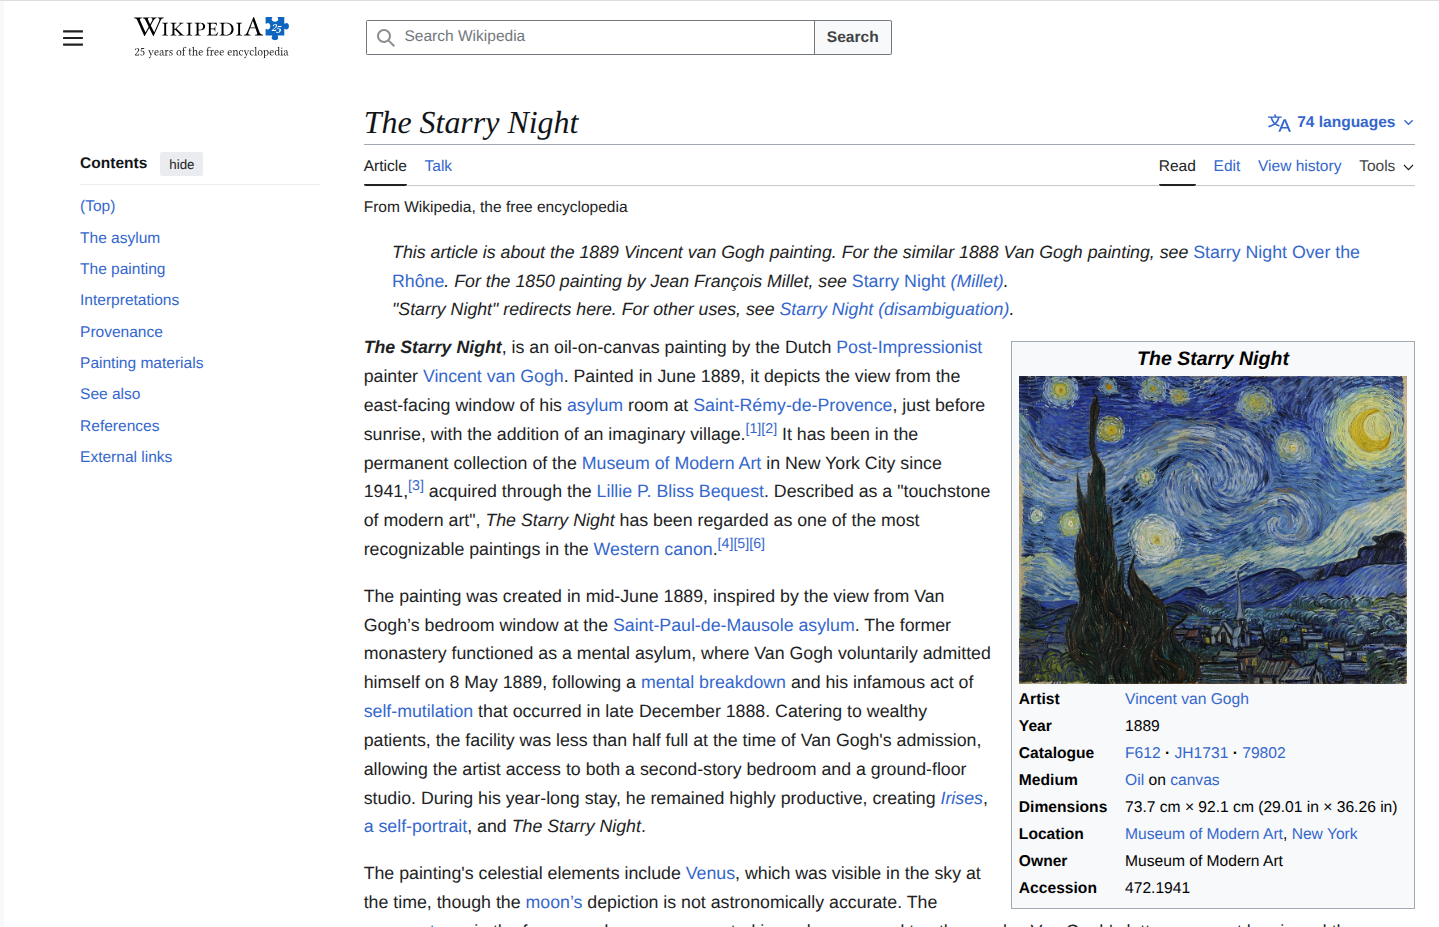

✅ Loaded: 2026-03-15_10-45.png


In [ ]:
import os
from PIL import Image
from IPython.display import display

state = {
    "image": None,
    "filename": None,
    "last_caption": None,
    "slow": False
}

supported = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
available = [f for f in os.listdir('/content/') if f.lower().endswith(supported)]

if not available:
    print("⚠️ No images found. Upload via 📁 sidebar first.")
else:
    filename = available[0]
    state["image"] = Image.open(f"/content/{filename}").convert("RGB")
    state["filename"] = filename
    display(state["image"])
    print(f"✅ Loaded: {filename}")

cell 5: Short Caption Audio Output

In [ ]:
if state["image"]:
    print("⏳ Generating short caption...")
    caption = describe_image(state["image"], mode="short")
    state["last_caption"] = caption
    print(f"📝 → {caption}")
    speak(caption, slow=state["slow"])

⏳ Generating short caption...
📝 → A webpage is displayed on a computer screen, featuring an article about Vincent Van Gogh's painting "The Starry Night."
🔊 Speaking: A webpage is displayed on a computer screen, featuring an article about Vincent Van Gogh's painting "The Starry Night."


cell 6: Detailed Caption Audio Output

In [ ]:
if state["image"]:
    print("⏳ Generating detailed description...")
    caption = describe_image(state["image"], mode="detailed")
    state["last_caption"] = caption
    print(f"📝 → {caption}")
    speak(caption, slow=state["slow"])

⏳ Generating detailed description...
📝 → The screen displays an article about Vincent Van Gogh's painting "The Starry Night." It features a large picture of his famous artwork with various descriptions surrounding it on different sides. There are also several other paintings displayed throughout the page as part of its content related to artists like Jean-François Millet.
🔊 Speaking: The screen displays an article about Vincent Van Gogh's painting "The Starry Night." It features a large picture of his famous artwork with various descriptions surrounding it on different sides. There are also several other paintings displayed throughout the page as part of its content related to artists like Jean-François Millet.
